In [64]:
# import os

# def create_subfolders(parent_directory, subfolder_names, nested_subfolder_names):
#     for folder_name in subfolder_names:
#         # Construct the full path for the new subfolder
#         subfolder_path = os.path.join(parent_directory, folder_name)
#         try:
#             # Create the main subfolder
#             os.makedirs(subfolder_path)
#             print(f"Created subfolder: {subfolder_path}")

#             # Create nested subfolders
#             for nested_folder_name in nested_subfolder_names:
#                 nested_subfolder_path = os.path.join(subfolder_path, nested_folder_name)
#                 os.makedirs(nested_subfolder_path)
#                 print(f"Created nested subfolder: {nested_subfolder_path}")
#         except OSError as error:
#             print(f"Error creating subfolder {subfolder_path}: {error}")

# # Define the parent directory
# parent_directory = "solns_runs/Ex5"

# # Generate main subfolder names T1, T2, ..., T50
# T_max= 3
# subfolder_names = [f"T{i}" for i in range(1, T_max)]

# # Generate nested subfolder names N100, N200, ..., N1500
# nested_subfolder_names = [f"N{i}" for i in range(100, 1501, 100)]

# # Create the subfolders
# create_subfolders(parent_directory, subfolder_names, nested_subfolder_names)

In [65]:
import numpy as np
import itertools
from scipy.optimize import minimize
import matplotlib.pyplot as plt


# Define objective functions for each player
def player1_objective(x):
    return x[0]**2-x[0]*x[1]-x[0]

def player2_objective(x):
    return x[1]**2-0.5*x[0]*x[1]-2*x[1]

def player3_objective(x):
    return (x[2]-0.5)**2

# Define constraints for each player
def constraint_function1(x):
    return 1.0 - (x[0]**2+x[1]**2)

def constraint_function2(x):
    return 1.0 - (x[2]+x[1])

# def grad_cons1(x):
#   return np.array([-3.25, -1.25, -4.125])

def constraint_function(x):
  return np.array([constraint_function1(x),constraint_function2(x)])

# def grad_cons2(x):
#   return np.array([-2.2911, -1.5625, -2.8125])

def grad_cons_x_1(x):
  return np.array([-2*x[0], 0.0])

def grad_cons_x_2(x):
  return np.array([-2*x[1], -1.0])

def grad_cons_x_3(x):
  return np.array([0.0, -x[2]])


b1 = [(0.0, 1.0)]
b2 = [(0.0, 1.0)]
b3 = [(0.0, 1.0)]
constraints = [
    {'type': 'ineq', 'fun': constraint_function1},
    {'type': 'ineq', 'fun': constraint_function2},
]

def F(x,lamd):
    return np.array([2*x[0]-x[1]-1+lamd@grad_cons_x_1(x),2*x[1]-0.5*x[0]-2+lamd@grad_cons_x_2(x), 2*(x[2]-0.5)+lamd@grad_cons_x_3(x)])

def project_into_feasible_set(x,constraint_function):
    result = minimize(lambda x_prime: np.linalg.norm(x_prime - x), x, constraints= constraints,bounds= [b1[0],b2[0], b3[0]])
    return result.x

# num_iterations= 100
def projected_gradient_descent_kkt(F,initial_x, initial_y, lambda_value,lamd):
    x = initial_x.copy()
    y = initial_y.copy()


    grad_obj = F(y,lamd)
    x = project_into_feasible_set(x - lambda_value * grad_obj,constraint_function)
    return x

n= 3
m= 2
def vi_solver(lamd):
    x = np.random.uniform(0, 1.0)
    y = np.random.uniform(0, 1.0)
    z = np.random.uniform(0, 1.0)
    x0 = np.array([x, y, z])
    y0= x0.copy()
    alpha= np.random.uniform(0, sqrt(2)-1)
    n= 3

    T= 1000
    x,y= np.zeros((T+1,n)),np.zeros((T+1,n))
    x[0]= x0
    y[0]= y0
    lambda_value_0= np.random.uniform(0, alpha)
#     print(x0)
    x[1]= projected_gradient_descent_kkt(F,x[0], y[0], lambda_value_0, lamd)
    y[1]= 2*x[1]-x[0]
    for i in range(1,T):

        if np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))!= 0.0:
            lambda_value= np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd)))
        else:
            lambda_value= 1e-8 # np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))+1e-8)
      # break
#         print(x[i])
        x[i+1]= projected_gradient_descent_kkt(F,x[i], y[i], lambda_value,lamd)
        y[i+1]= 2*x[i+1]-x[i]
#         print(x[i+1])
        
#         print(np.linalg.norm(x[i+1] - x[i]))
        
        if (np.linalg.norm(x[i+1] - x[i])) <= 1e-4:
            if np.all(np.abs(constraint_function(x[i+1]) * lamd) <= 1e-4):
                return x[i+1]


In [66]:
import random

def discretize_3d_space(T, num_points):
    """
    Sample num_points random points in 2D domain [0, T] x [0, T].

    Parameters:
    - T: Upper bound of domain
    - num_points: Total number of 2D points

    Returns:
    - points: List of (x, y) tuples
    """
    points = [(random.uniform(0, T), random.uniform(0, T)) 
              for _ in range(num_points)]
    
    return points

In [67]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
# from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()


eps_t= 1e-5
delta= 1e-3 #1e-2
delta

def calculate_distance(point1, point2):
    # Calculate the Euclidean distance between two points of any dimension
    return sum((x - y)** 2 for x, y in zip(point1, point2)) ** 0.5
#     return sum(abs(x - y) for x, y in zip(point1, point2))

    
# delta= 0.00001 #1e-2
def count_repeated_points(points):
    # Initialize a list to store distinct points
    distinct_points = []

    # Iterate through each point in the set
    for point in points:
        # Check if the point is distinct from all previously considered distinct points
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < delta:
                is_distinct = False
                break
        # If the point is distinct, add it to the list of distinct points
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points



def organize_solutions(solns):
    set_of_points= []
    for sol in solns:
        if sol is not None:
            set_of_points.append(list(sol))

    return set_of_points




def run_for_lam(lmb):
    results = Parallel(n_jobs=8,prefer= 'threads')(delayed(vi_solver)(lam) for lam in lmb)
    set_of_points= organize_solutions(results)
    return set_of_points

def run_(lambd):
    results = Parallel(n_jobs=-1,prefer= 'threads')(delayed(run_for_lam)(lam) for lam in lambd)
    set_of_points= organize_solutions(results)
    return set_of_points

def run_n(lmb, n_r= 10):
    results = Parallel(n_jobs=8)(delayed(run_for_lam)(lmb) for _ in range(n_r))
    set_of_points= organize_solutions(results)
    res= []
    for i in set_of_points:
        res.extend(i)
    return np.array(res)


def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=-1,prefer= 'threads')(delayed(run_)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points


# def run_for_different_runs(T,n_r= 5):
#     lambd = Parallel(n_jobs=-1,prefer= 'threads')(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
#     result= run_for_lam_run(lambd,n_r)
#     #return result.
#     for idx_run in range(n_r):
#         results= result[idx_run]
#         for n_points in range(len(results)):
#             np.savetxt('./solns_runs/Ex5/T'+str(T)+'/'+'N'+str(number_points_list[n_points])+"/"+str(idx_run+1)+"_"+"solns"+'_'+'run'+str(n_r)+'_'+str(number_points_list[n_points])+'pts'+'.txt', np.array(results[n_points]), delimiter=',')
            
        

    
# Parallel(n_jobs=-1,prefer= 'threads')(delayed(run_for_different_runs)(T) for T in T_list)

In [69]:
number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
# n_runs= [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60]
# number_points_list= [10, 20]
# T_list= [T for T in range(1,T_max)]
# n_runs= [5]
# T= 1
# lambd= Parallel(n_jobs=-1)(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
# lambd

In [70]:
# lambd[0]

In [71]:
# len(lambd[1])

In [72]:
# n_runs= 10

In [73]:
# vi_solver(lamd=(0.0,0.0))

In [74]:
# len(lambd[0])

In [75]:
# T= 4 # vary T.
# lambd = Parallel(n_jobs=6)(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
# lambd

In [76]:
# data= []
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [77]:
# all_data= dict.fromkeys(range(len(data)), 0)

# for i in range(len(data)):
#     all_data[i]= data[i]

# import json
# with open("Ex2NonsolPVIT{}.json".format(T), "w") as f:
#     json.dump(all_data, f)

In [78]:
# tt= run_for_lam(lambd[0])

In [79]:
# fig = plt.figure(figsize=(15,6))
# ax = fig.add_subplot(111, projection='3d')

# # Plot the curve in 3D
# ax.scatter(np.array(all_data[1])[:,0], np.array(all_data[1])[:,1], np.array(all_data[1])[:,2], c= 'black', label= "Solution set")
# # ax.set_xlim(0.0, 8.0)
# # ax.set_ylim(3.0, 11.)
# # ax.set_zlim(0.0, 8.0)
# ax.set_xlabel(r'$x_1$')
# ax.set_ylabel(r'$x_2$')
# ax.set_zlabel(r'$x_3$')

# plt.legend()
# # ax.set_title("Solution set found by VPI")
# # plt.savefig('Ex1.jpeg', format='jpeg')
# # fig.savefig('ex1.png', dpi=180, bbox_inches='tight')
# # plt.savefig('Ex5.png', dpi=180, bbox_inches='tight')
# plt.show()

In [80]:
# All T
## New
## Load data

import json

# with open('../Scripts/PVI/Ex3PVI.json') as f:
#     data= json.load(f)

with open('./Ex2NonsolPVIT1.json') as f:
    dataT1= json.load(f)

with open('./Ex2NonsolPVIT2.json') as f:
    dataT2= json.load(f)
    
with open('./Ex2NonsolPVIT3.json') as f:
    dataT3= json.load(f)
    
with open('./Ex2NonsolPVIT4.json') as f:
    dataT4= json.load(f)
    
with open('./Ex2NonsolPVIT5.json') as f:
    dataT5= json.load(f)

In [81]:
dataT= [dataT1, dataT2, dataT3, dataT4, dataT5]

In [82]:


T_list= [1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict


for (idx, T) in enumerate(T_list):
    data_all= []

    for i in range(len(number_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[idx][str(i)])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[idx][str(i)]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[idx][str(i)])):
                # print(data[str(i)][t])
                # if constraint_function(dataT[str(T)][i][t])<= 1e-8:
                if dataT[idx][str(i)][t] != [0, 0, 0]:
                    if np.all(np.abs(constraint_function(dataT[idx][str(i)][t]))): # np.abs(constraint_function(dataT[idx][str(i)][t]))<= 1e-6:
                        res_.append(dataT[idx][str(i)][t])
            data_all.append(res_)
    data_dict[T]= data_all

res_all= []

for i in range(len(number_points_list)):
    res= []
    for T in T_list:
        res.extend(dataT[idx][str(i)])

    res_all.append(res)

data_all= res_all
data= data_all

Plot for 100 points


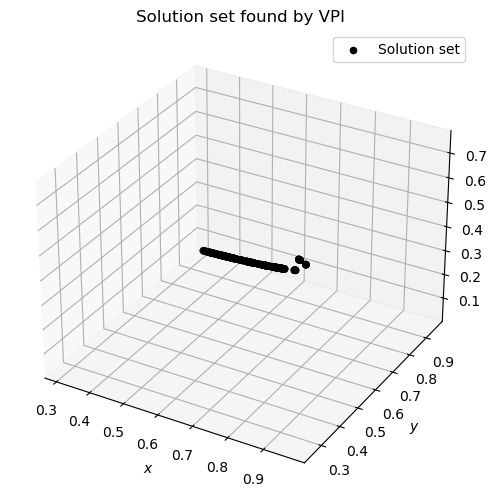

Plot for 200 points


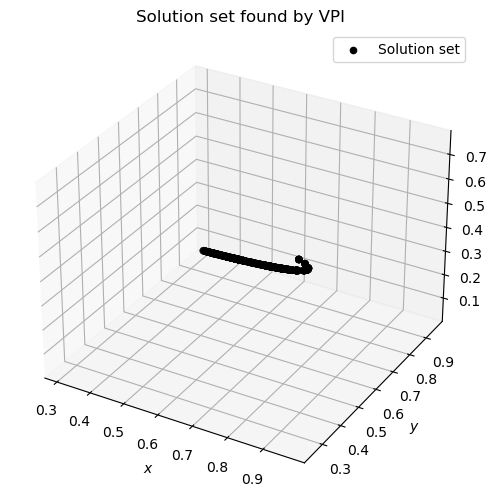

Plot for 300 points


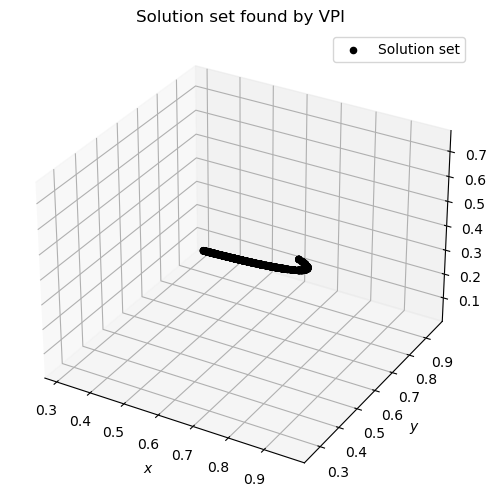

Plot for 400 points


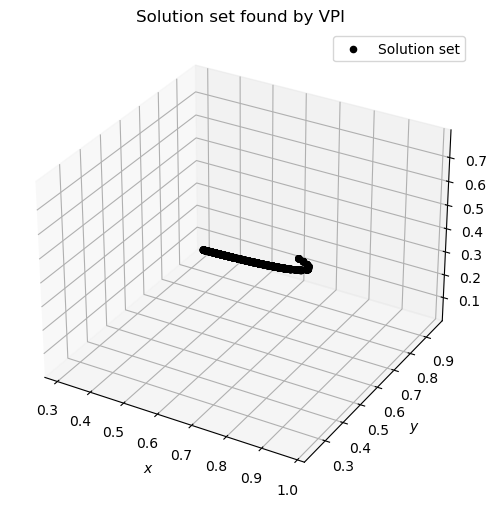

Plot for 500 points


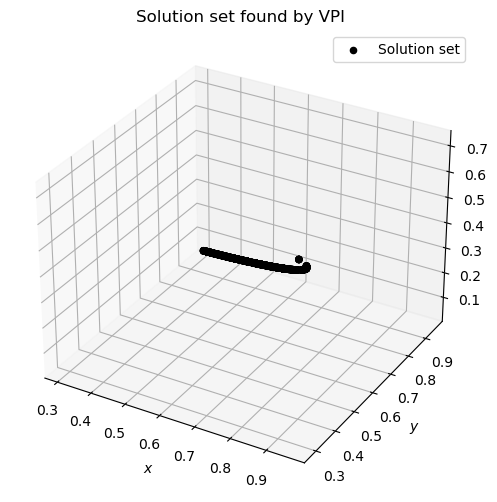

Plot for 600 points


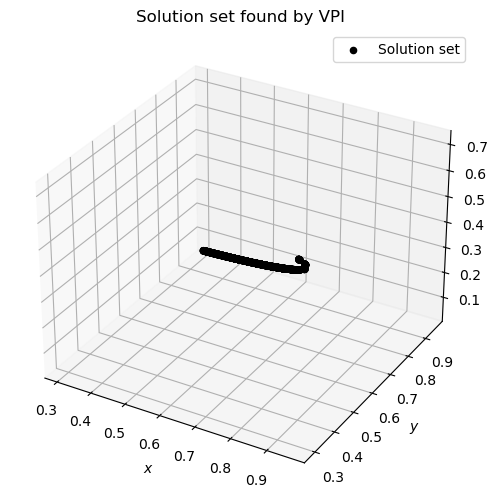

Plot for 700 points


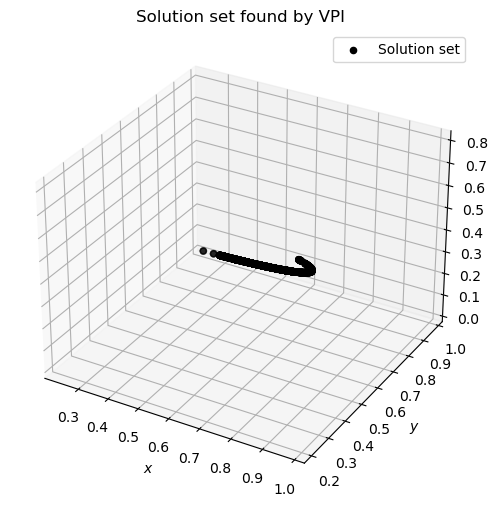

Plot for 800 points


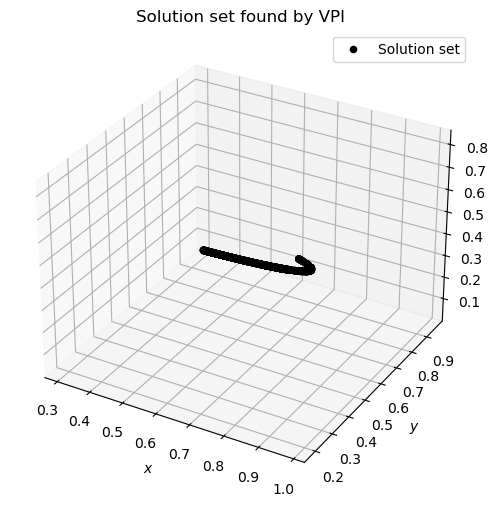

Plot for 900 points


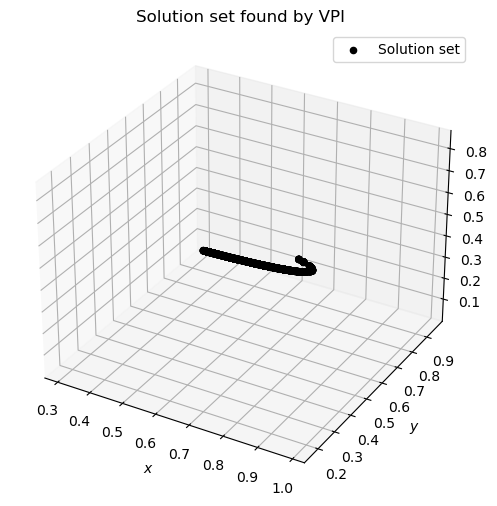

Plot for 1000 points


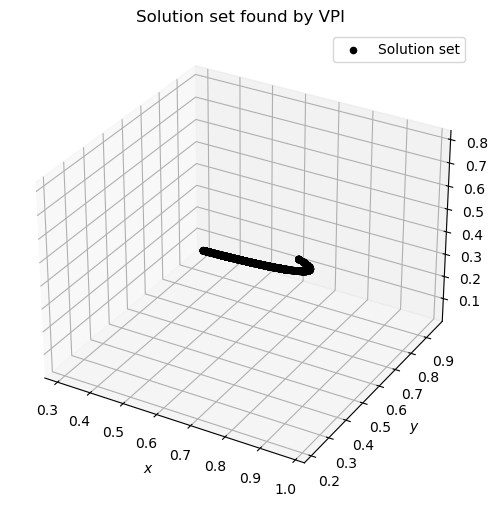

Plot for 1100 points


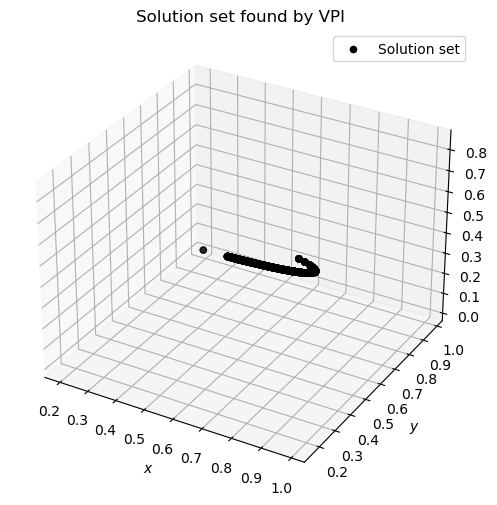

Plot for 1200 points


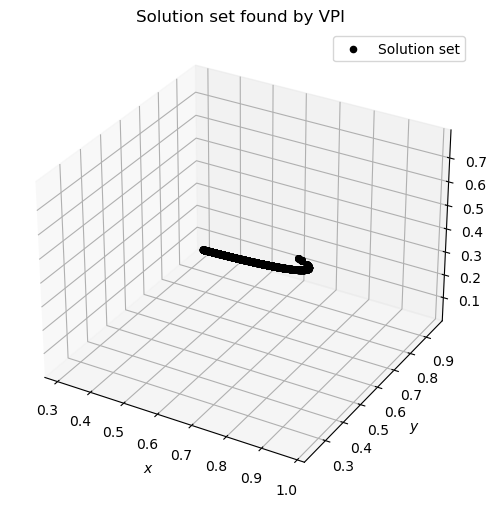

Plot for 1300 points


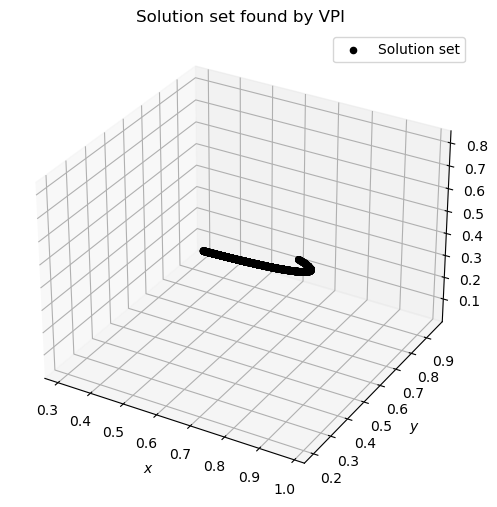

Plot for 1400 points


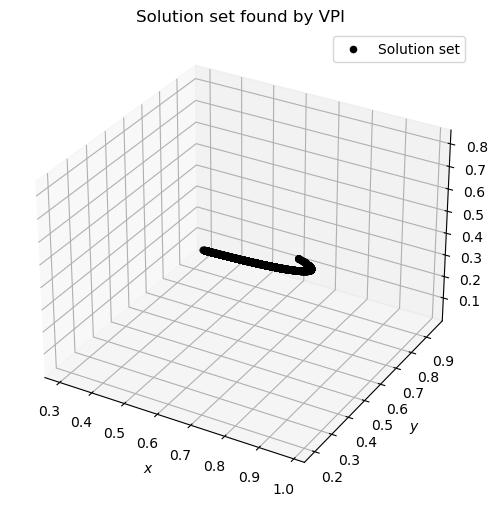

Plot for 1500 points


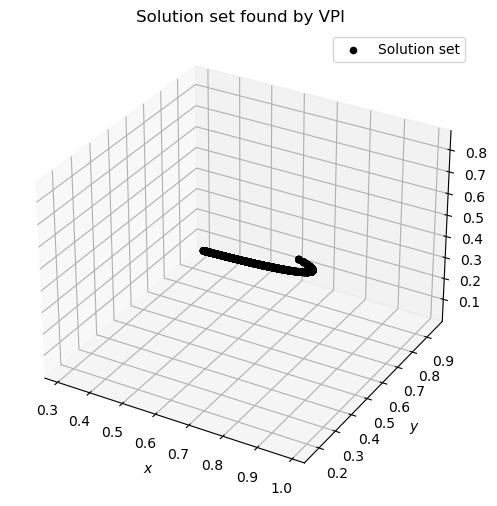

In [85]:
for i in range(len(data)):
    print("Plot for {} points".format(number_points_list[i]))
    
    fig = plt.figure(figsize=(15,6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the curve in 3D
    ax.scatter(np.array(data[i])[:,0], np.array(data[i])[:,1], np.array(data[i])[:,2], c= 'black', label= "Solution set")
    # ax.set_xlim(0.0, 8.0)
    # ax.set_ylim(3.0, 11.)
    # ax.set_zlim(0.0, 8.0)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_zlabel(r'$z$')

    plt.legend()
    ax.set_title("Solution set found by VPI")
    # plt.savefig('Ex1.jpeg', format='jpeg')
    # fig.savefig('ex1.png', dpi=180, bbox_inches='tight')
    plt.savefig('Ex2Nonsol{}.png'.format(str(number_points_list[i])), dpi=180, bbox_inches='tight')
    plt.show()


#     plt.scatter(np.array(data[i])[:,0], np.array(data[i])[:,1], c= 'black')
#     plt.xlim([0,1])
#     plt.ylim([0,1])
#     plt.grid(True)
#     plt.show()

In [136]:
# lambd = Parallel(n_jobs=6)(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
# lambd

In [138]:
# data= []
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


In [139]:
# data= np.array(data)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (15,) + inhomogeneous part.

In [149]:
# data[0]

[[0.0, 11.0, 8.0],
 [0.0, 11.0, 7.999999999999999],
 [7.966717563423487e-16, 11.0, 7.999999999999999],
 [0.0, 10.894094886335797, 7.788189772671594],
 [3.0449030485066467e-16, 10.962627105061319, 7.925254210122638],
 [2.3592239273284576e-16, 11.0, 8.0],
 [2.7755575615628914e-16, 10.949411995495389, 7.898823990990778],
 [0.0018226115763355386, 10.998177388423665, 7.998177388423665],
 [0.0, 11.0, 7.999999999999999],
 [2.3592239273284576e-16, 11.0, 8.0],
 [3.3306690738754696e-16, 11.0, 8.0],
 [6.469240267077939e-16, 10.787477940102493, 7.5749558802049854],
 [0.0, 11.0, 7.999999999999999],
 [0.0009967106255215736, 10.999003289374478, 7.999003289374478],
 [0.0, 11.0, 7.999999999999999],
 [0.0, 11.0, 8.0],
 [0.0, 11.0, 8.0],
 [0.0, 10.75766351778857, 7.515327035577141],
 [0.0, 11.0, 8.0],
 [7.322074506813949e-05, 10.999926779254931, 7.999926779254933],
 [8.673617379884035e-17, 11.0, 7.999999999999999],
 [2.983724378680108e-16, 11.0, 8.0],
 [0.0, 11.0, 7.999999999999999],
 [1.0668549377257364

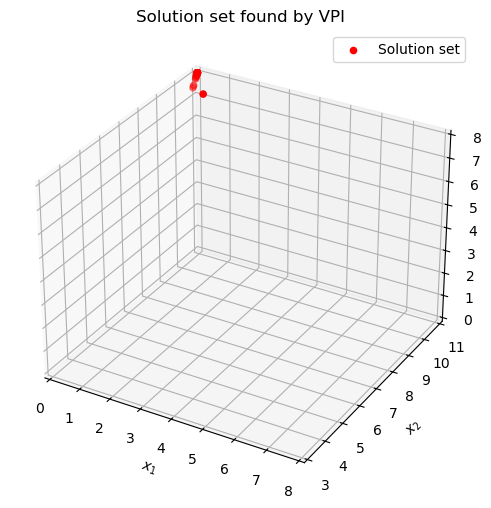

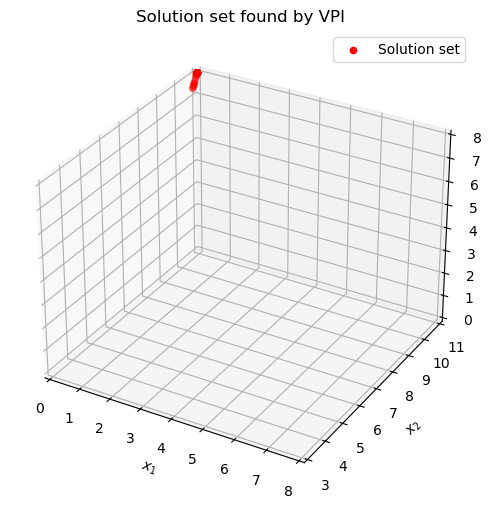

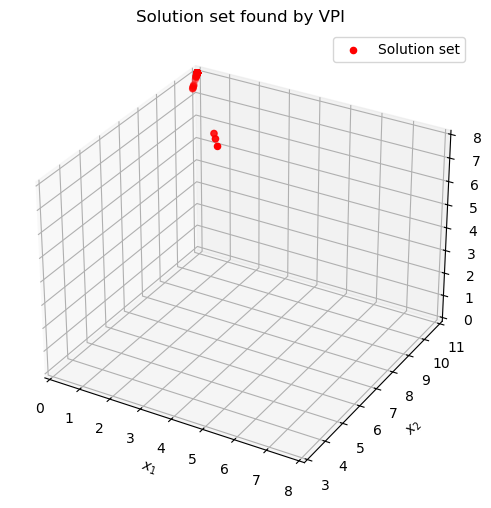

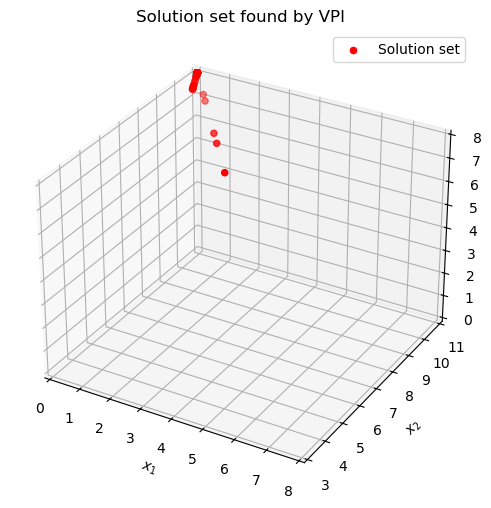

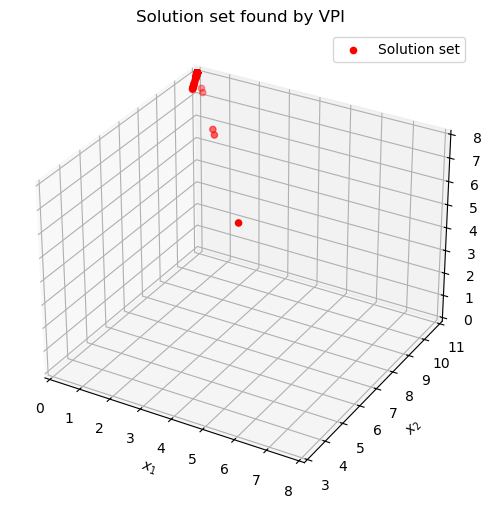

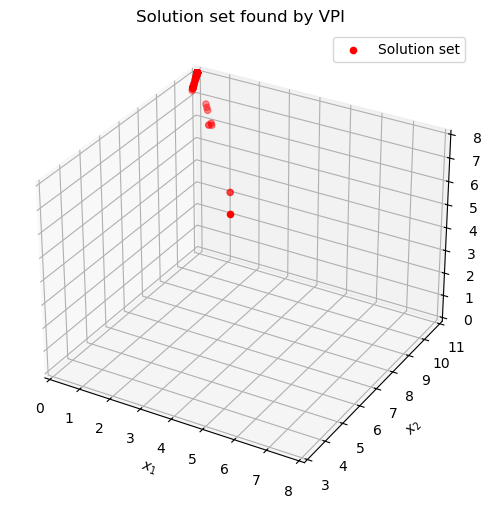

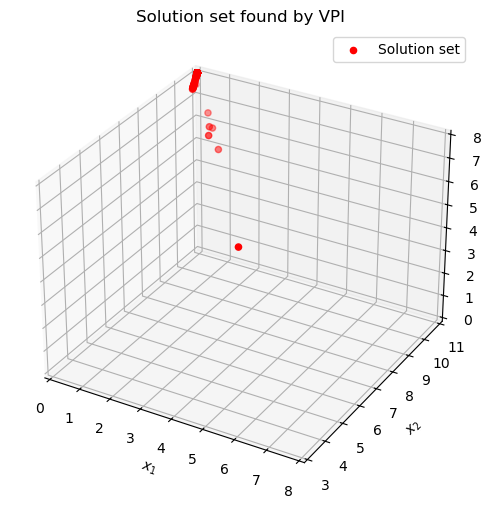

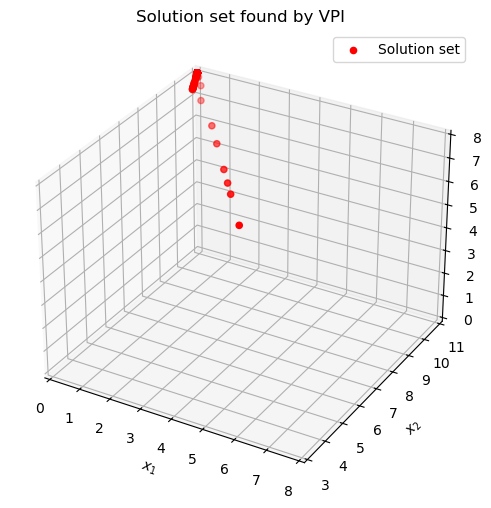

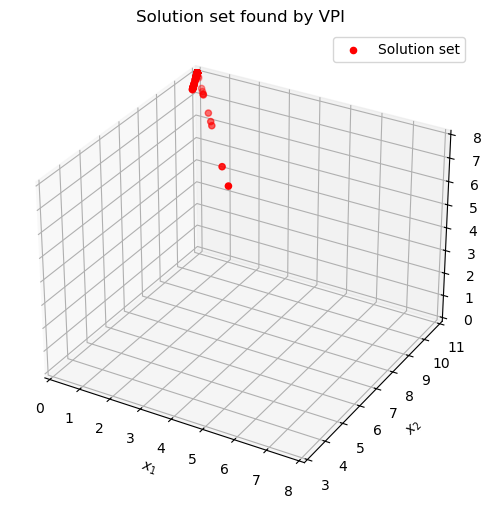

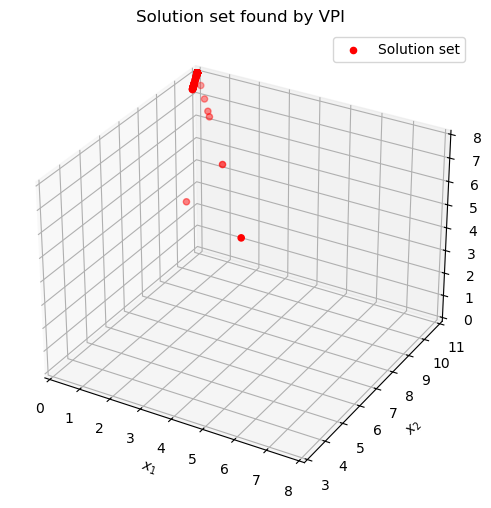

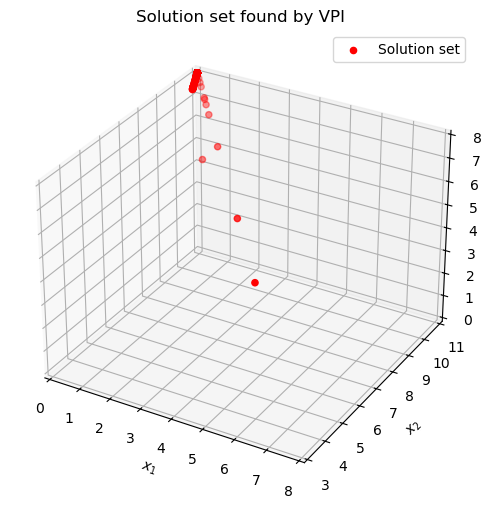

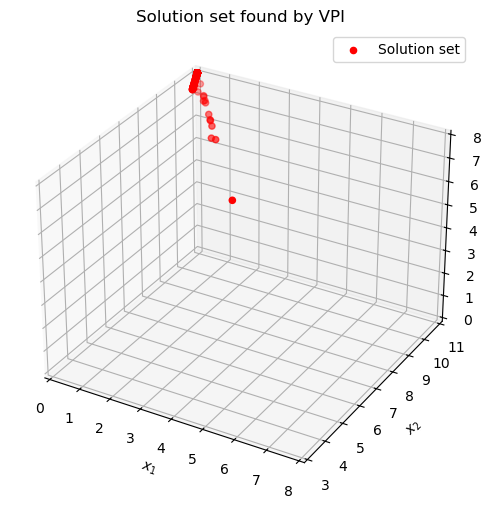

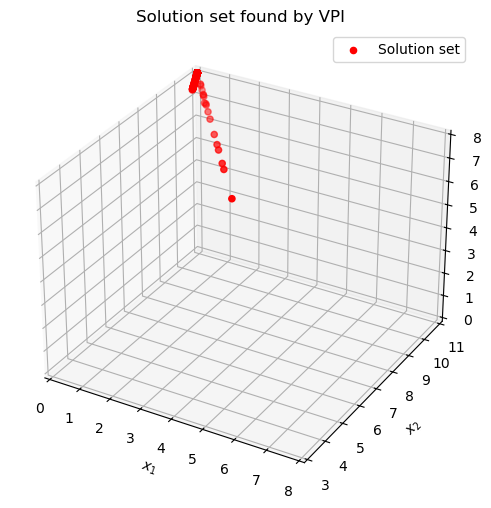

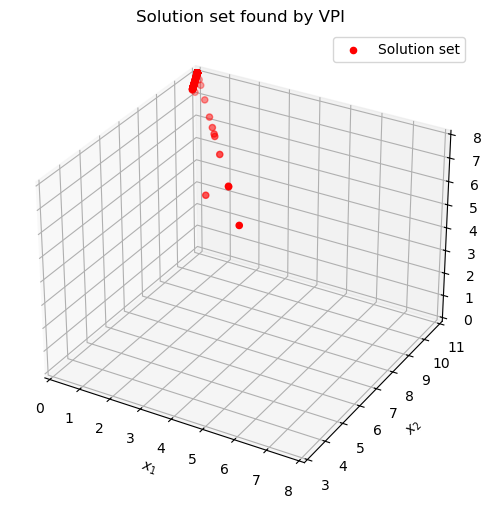

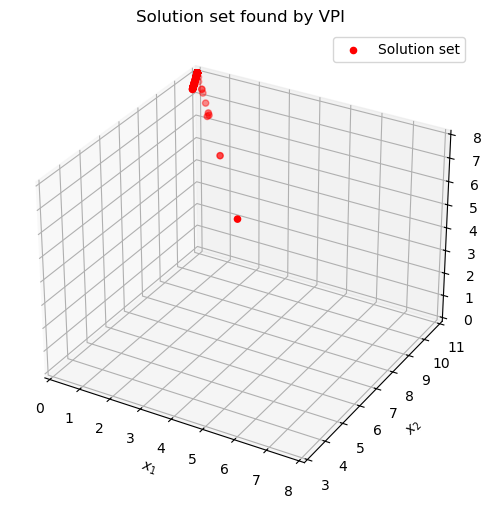

In [157]:
# for i in range(len(data)):
#     fig = plt.figure(figsize=(15,6))
#     ax = fig.add_subplot(111, projection='3d')
    
#     # Plot the curve in 3D
#     ax.scatter(np.array(data[i])[:,0], np.array(data[i])[:,1], np.array(data[i])[:,2], c= 'red', label= "Solution set")
#     ax.set_xlim(0.0, 8.0)
#     ax.set_ylim(3.0, 11.)
#     ax.set_zlim(0.0, 8.0)
#     ax.set_xlabel(r'$x_1$')
#     ax.set_ylabel(r'$x_2$')
#     ax.set_zlabel(r'$x_3$')
    
#     plt.legend()
#     ax.set_title("Solution set found by VPI")
#     # plt.savefig('Ex1.jpeg', format='jpeg')
#     # fig.savefig('ex1.png', dpi=180, bbox_inches='tight')
#     # plt.savefig('Ex5.png', dpi=180, bbox_inches='tight')
#     plt.show()

In [122]:
# lambd = Parallel(n_jobs=6)(delayed(discretize_3d_space)(1, num_points) for num_points in number_points_list)

In [126]:
# res= runT(T= 2)

KeyboardInterrupt: 

In [63]:
## All T

In [ ]:
def runT(T):
    lambd = Parallel(n_jobs=6)(delayed(discretize_3d_space)(T, num_points) for num_points in number_points_list)
    data= []
    for l in range(len(lambd)):
        res= run_n(lambd[l])
        data.append(res)
    return data

In [ ]:
T_list= [1, 2, 3, 4, 5]

T_data= dict.fromkeys(range(1, len(T_list)+1), 0)

T_data

In [ ]:
for T in T_list:
    print("Running for T= ", T)
    res= runT(T)
    T_data[T]= res
    print(len(res))

In [ ]:
import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex2NonsolPVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

In [29]:
# data= []

In [79]:
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [81]:
# all_data= dict.fromkeys(range(len(data)), 0)
# for i in range(len(data)):
#     all_data[i]= data[i]
    
# import json
# with open("Ex5PVI.json", "w") as f:
#     json.dump(all_data, f)